# COVID-19 Data Analysis Project (Python + PostgreSQL)

## Project Description

This project focuses on performing an end-to-end data analysis of the global COVID-19 pandemic using real-world data. The analysis is conducted using Python for data processing, visualization, and feature engineering, along with PostgreSQL for structured querying and insight extraction.

The dataset used in this project is sourced from the Our World in Data COVID-19 dataset available on Kaggle, which contains detailed information on COVID-19 cases, deaths, and vaccination trends across multiple countries over time.


## Problem Statement

The COVID-19 pandemic generated massive amounts of global data, but extracting meaningful insights from this data is challenging due to its size, inconsistency, and missing values.

The problem addressed in this project is:

* How can we analyze global COVID-19 data to identify trends in cases, deaths, and vaccinations?
* How can we clean and preprocess real-world data to make it suitable for analysis?
* How can we use visualization techniques to understand patterns over time?
* How can SQL be used to extract meaningful insights from structured data?

This project aims to solve these challenges by building a complete data analysis pipeline using Python and PostgreSQL.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

In [2]:
df = pd.read_csv('/content/owid-covid-data.csv')

df.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-03,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-04,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-05,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-06,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-07,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN


### Understand Data

In [3]:
print(df.shape)

(200483, 67)


In [4]:
print(df.columns)

Index(['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases',
       'new_cases_smoothed', 'total_deaths', 'new_deaths',
       'new_deaths_smoothed', 'total_cases_per_million',
       'new_cases_per_million', 'new_cases_smoothed_per_million',
       'total_deaths_per_million', 'new_deaths_per_million',
       'new_deaths_smoothed_per_million', 'reproduction_rate', 'icu_patients',
       'icu_patients_per_million', 'hosp_patients',
       'hosp_patients_per_million', 'weekly_icu_admissions',
       'weekly_icu_admissions_per_million', 'weekly_hosp_admissions',
       'weekly_hosp_admissions_per_million', 'total_tests', 'new_tests',
       'total_tests_per_thousand', 'new_tests_per_thousand',
       'new_tests_smoothed', 'new_tests_smoothed_per_thousand',
       'positive_rate', 'tests_per_case', 'tests_units', 'total_vaccinations',
       'people_vaccinated', 'people_fully_vaccinated', 'total_boosters',
       'new_vaccinations', 'new_vaccinations_smoothed',
       't

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200483 entries, 0 to 200482
Data columns (total 67 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   iso_code                                    200483 non-null  object 
 1   continent                                   190763 non-null  object 
 2   location                                    200483 non-null  object 
 3   date                                        200483 non-null  object 
 4   total_cases                                 184742 non-null  float64
 5   new_cases                                   196945 non-null  float64
 6   new_cases_smoothed                          196225 non-null  float64
 7   total_deaths                                175026 non-null  float64
 8   new_deaths                                  196972 non-null  float64
 9   new_deaths_smoothed                         196257 non-null  float64
 

In [6]:
df.describe()

,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,total_cases_per_million,new_cases_per_million,new_cases_smoothed_per_million,total_deaths_per_million,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
count,1.847420e+05,1.969450e+05,1.962250e+05,1.750260e+05,196972.000000,196257.000000,184742.000000,196945.000000,196225.000000,175026.000000,...,114995.000000,80338.000000,140260.000000,185304.000000,156469.000000,2.004820e+05,7615.000000,7615.000000,7615.000000,7615.000000
mean,5.860444e+06,8.786611e+03,8.818531e+03,6.447405e+04,67.466178,67.710460,105682.370946,152.044976,152.594781,871.801849,...,33.105438,50.368983,2.966890,73.726754,0.721961,1.264788e+08,39358.633543,9.889652,11.518923,1655.714519
std,3.184373e+07,1.047228e+05,8.416148e+04,2.744143e+05,474.479657,392.115275,158516.280692,1052.258092,575.376882,1074.349282,...,14.187479,33.545898,2.380045,7.596650,0.151247,5.329227e+08,105374.992117,12.414221,25.902045,1989.178792
min,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,7.700000,1.188000,0.100000,53.280000,0.397000,3.801000e+03,-37726.098000,-33.050000,-70.590000,-2752.924800
25%,9.664000e+03,0.000000e+00,8.570000e-01,1.440000e+02,0.000000,0.000000,2846.498500,0.000000,0.174000,59.083250,...,20.600000,16.603000,1.300000,68.370000,0.611000,5.237980e+05,106.700000,1.500000,-1.620000,77.454290
50%,7.078200e+04,3.000000e+00,3.085700e+01,1.000000e+03,0.000000,0.143000,27936.479000,0.358000,8.178000,401.777000,...,33.100000,52.232000,2.200000,75.050000,0.744000,5.489744e+06,4453.499000,7.690000,5.970000,1052.541100
75%,6.435050e+05,2.950000e+02,5.074290e+02,1.042775e+04,3.000000,5.286000,136031.251000,39.831000,90.027000,1372.229000,...,44.400000,83.841000,4.200000,79.930000,0.845000,2.267376e+07,31247.352500,15.685000,16.895000,2751.056550
max,4.259884e+08,7.213802e+06,6.109825e+06,2.914272e+06,20625.000000,8584.857000,737554.506000,193107.077000,31207.174000,5664.148000,...,76.100000,98.999000,13.800000,86.750000,0.955000,4.721383e+09,902478.100000,70.810000,377.630000,10292.916000


### Select Relevant Columns

In [8]:
df = df[['location','date','total_cases',
         'new_cases','total_deaths','new_deaths','total_vaccinations']]

In [9]:
df.head()

,location,date,total_cases,new_cases,total_deaths,new_deaths,total_vaccinations
0,Afghanistan,2020-01-03,NaN,0.0,NaN,0.0,NaN
1,Afghanistan,2020-01-04,NaN,0.0,NaN,0.0,NaN
2,Afghanistan,2020-01-05,NaN,0.0,NaN,0.0,NaN
3,Afghanistan,2020-01-06,NaN,0.0,NaN,0.0,NaN
4,Afghanistan,2020-01-07,NaN,0.0,NaN,0.0,NaN


### Data Cleaning

In [10]:
df.isnull().sum()

,0
location,0
date,0
total_cases,15741
new_cases,3538
total_deaths,25457
new_deaths,3511
total_vaccinations,151214


In [11]:
df = df.fillna(0)

In [12]:
df.isnull().sum()

,0
location,0
date,0
total_cases,0
new_cases,0
total_deaths,0
new_deaths,0
total_vaccinations,0


In [13]:
df['date'] = pd.to_datetime(df['date'])

### Feature Engineering

In [15]:
df['death_rate'] = df['total_deaths'] / df['total_cases']

df['death_rate'] = df['death_rate'].replace([np.inf,-np.inf],0)

df['death_rate'] = df['death_rate'].fillna(0)

In [16]:
df['death_rate'].head()

,death_rate
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


### Filter India Data

In [17]:
india_df = df[df['location'] == "India"]

In [20]:
india_df.head()

,location,date,total_cases,new_cases,total_deaths,new_deaths,total_vaccinations,death_rate
139773,India,2020-01-03,0.0,0.0,0.0,0.0,0.0,0.0
139774,India,2020-01-04,0.0,0.0,0.0,0.0,0.0,0.0
139775,India,2020-01-05,0.0,0.0,0.0,0.0,0.0,0.0
139776,India,2020-01-06,0.0,0.0,0.0,0.0,0.0,0.0
139777,India,2020-01-07,0.0,0.0,0.0,0.0,0.0,0.0


### Data Visualization

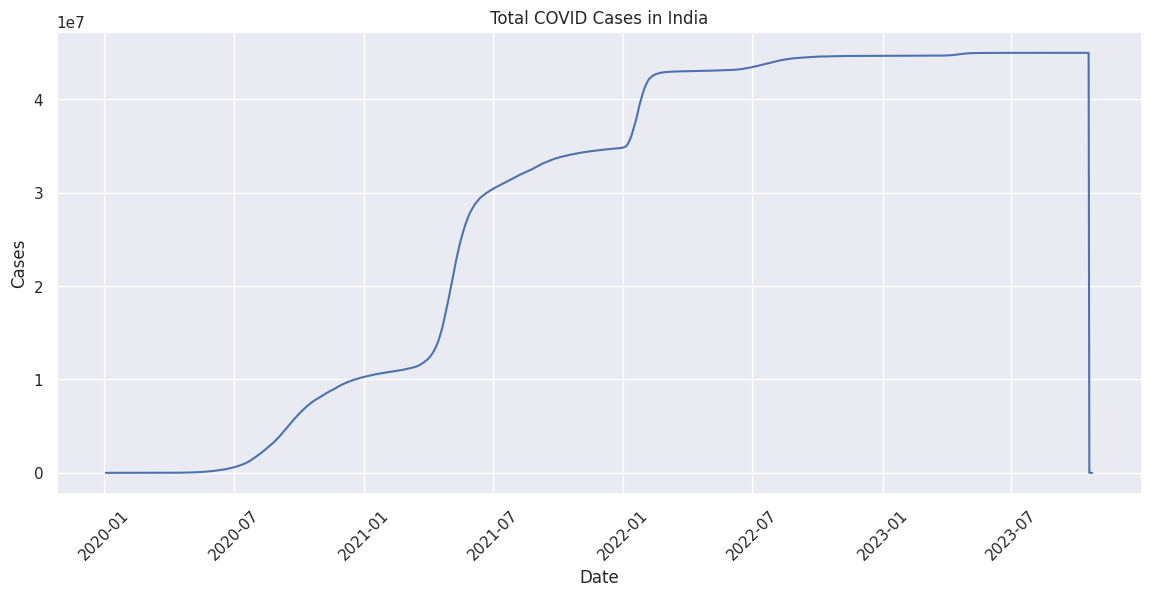

In [21]:
# Total cases over time


plt.figure(figsize=(14, 6))
plt.plot(india_df['date'], india_df['total_cases'])

plt.title("Total COVID Cases in India")
plt.xlabel("Date")
plt.ylabel("Cases")
plt.xticks(rotation=45)
plt.show()

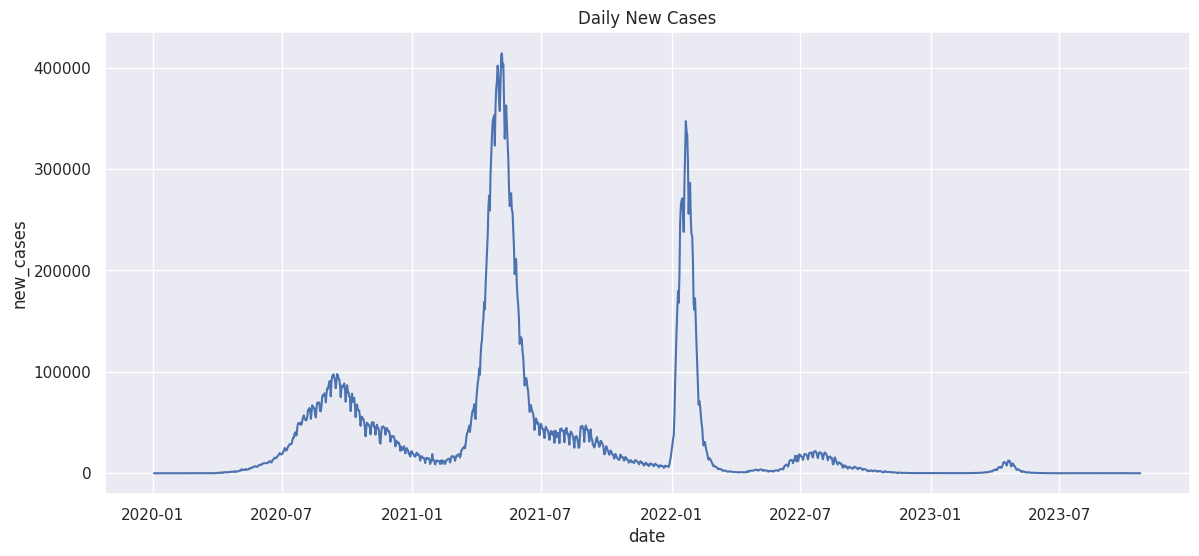

In [22]:
# New Cases Trend

plt.figure(figsize=(14,6))
sns.lineplot(x='date', y='new_cases', data=india_df)
plt.title("Daily New Cases")
plt.show()

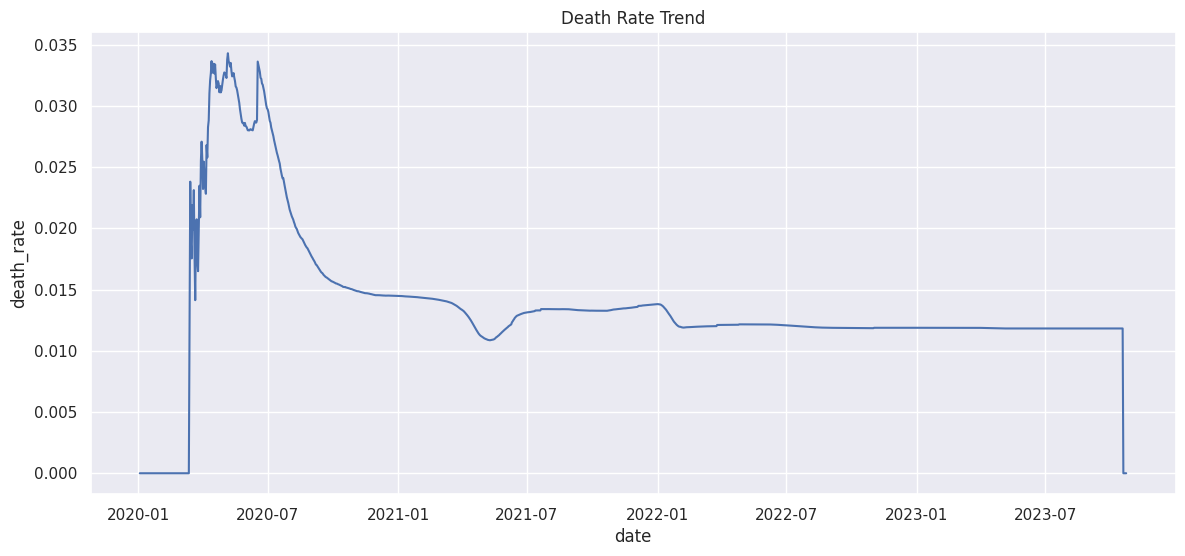

In [23]:
# Death Rate Trend

plt.figure(figsize=(14, 6))
sns.lineplot(x='date',y='death_rate',data=india_df)
plt.title("Death Rate Trend")
plt.show()

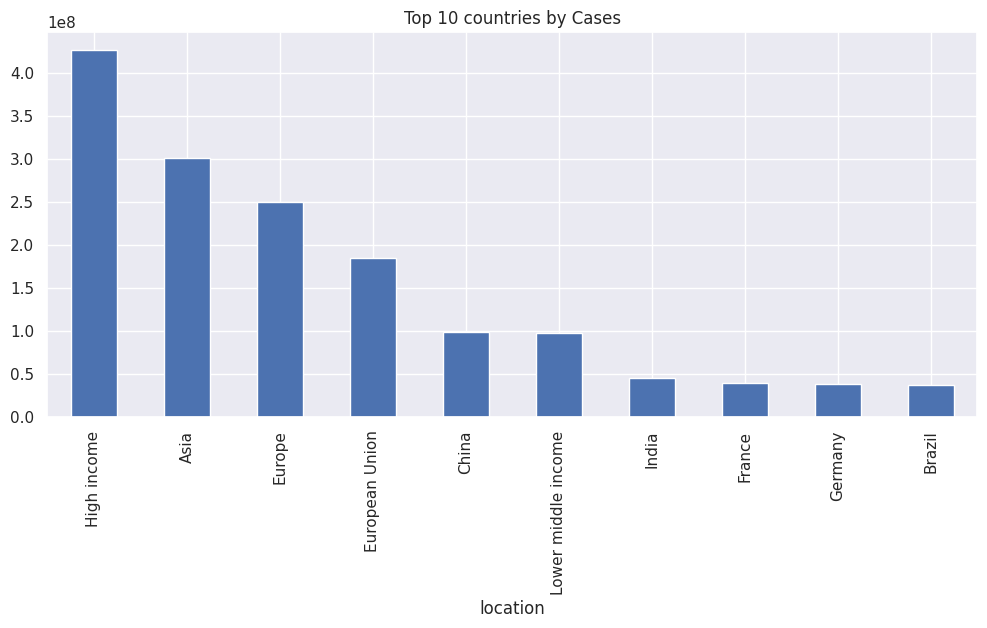

In [24]:
# Top 10 countries

top_countries = df.groupby('location')['total_cases'].max().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,5))
top_countries.plot(kind='bar')
plt.title("Top 10 countries by Cases")
plt.show()

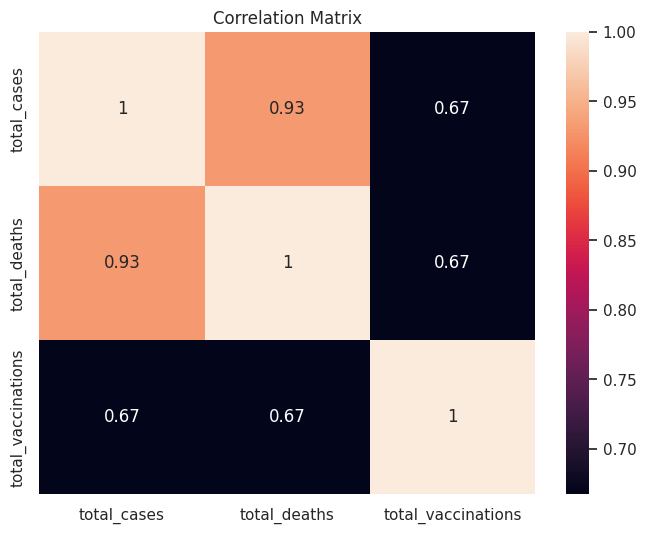

In [25]:
# Correlation Heatmap

plt.figure(figsize=(8,6))
sns.heatmap(df[['total_cases','total_deaths','total_vaccinations']].corr(),annot=True)
plt.title("Correlation Matrix")
plt.show()

### Export Clean Data

In [26]:
df.to_csv('cleaned_covid_data.csv',index=False)